### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv("diabetic_data.csv")

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

### Data Understanding

In [11]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
(df=='?').sum().sort_values(ascending=False)

In [15]:
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'], inplace=True)   

- These columns contained a large proportion of missing values and were removed to improve data quality.

In [23]:
df['race'] = df['race'].fillna('Unknown')
df['payer_code'] = df['payer_code'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown') 
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

- Missing categorical values were replaced with **"Unknown"** to preserve records while indicating unavailable information.

### Target Variable Encoding

In [33]:
df['readmitted'] = df['readmitted'].apply(lambda x : 1 if x == '<30' else 0)

In [35]:
df['readmitted'].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

- Patients readmitted within 30 days were labeled as 1, while all other cases were labeled as 0.

### Remove Identifier Columns

In [40]:
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)      

- Unique identifiers were removed since they do not contribute to prediction.

### Exploratory Data Analysis

#### Distribution of Target Variable

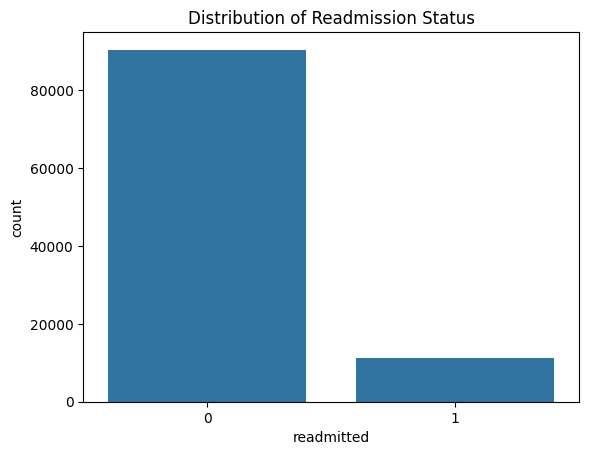

In [57]:
sns.countplot(data=df, x='readmitted')
plt.title('Distribution of Readmission Status')
plt.show()

- The dataset is imbalanced with significantly fewer patients readmitted within 30 days.

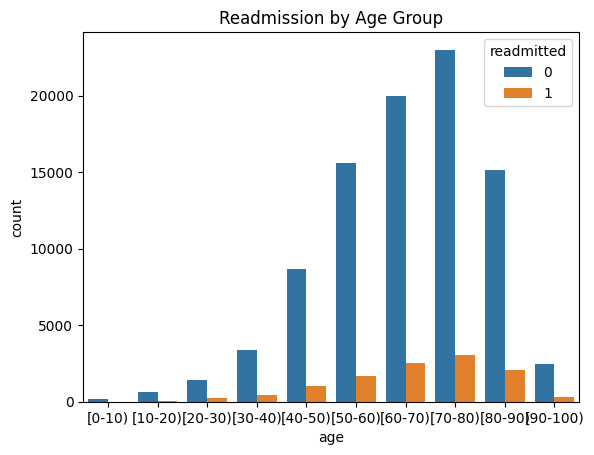

In [59]:
sns.countplot(data=df, x='age', hue='readmitted')
plt.title('Readmission by Age Group')
plt.show()

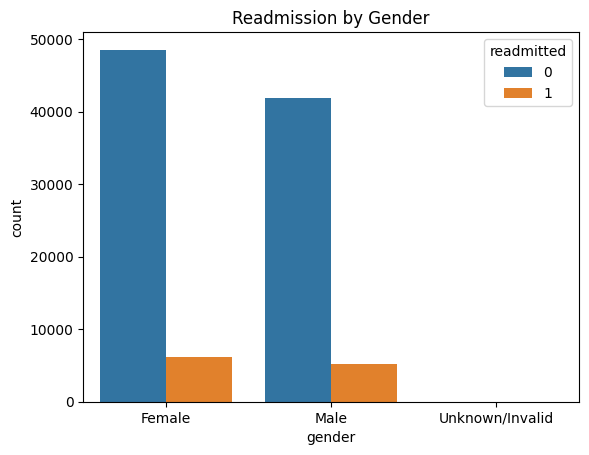

In [60]:
sns.countplot(data=df, x='gender', hue='readmitted')
plt.title('Readmission by Gender')
plt.show()

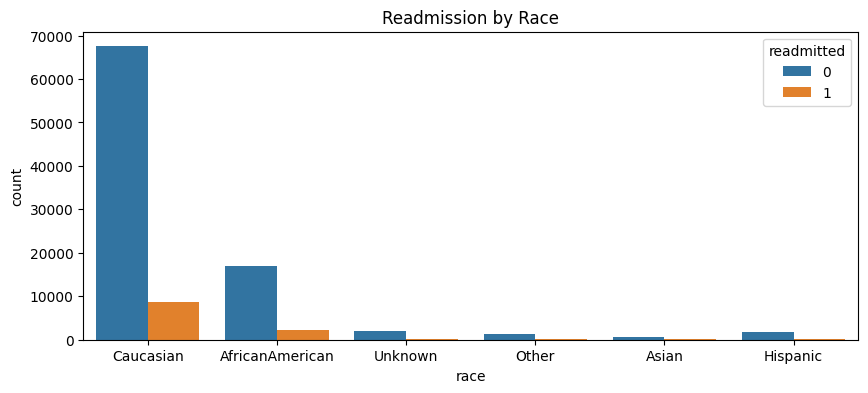

In [64]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='race', hue='readmitted')
plt.title('Readmission by Race')
plt.show()

#### Numerical Feature Analysis

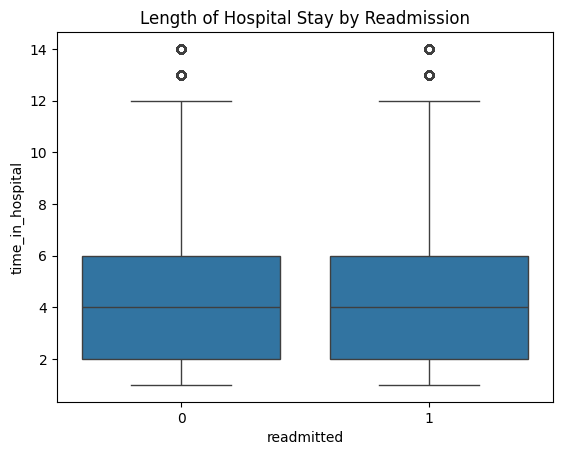

In [66]:
sns.boxplot(data=df, x='readmitted', y='time_in_hospital')
plt.title('Length of Hospital Stay by Readmission')
plt.show()

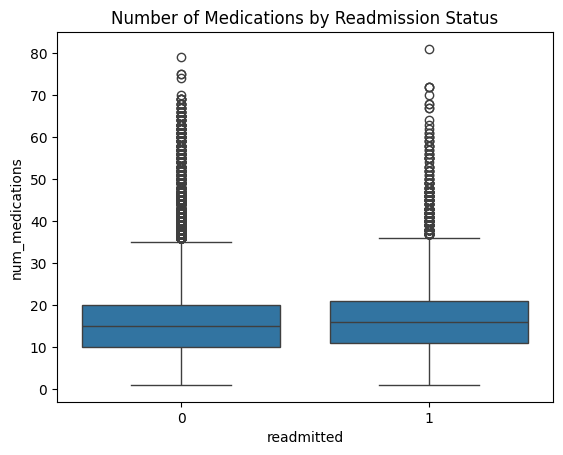

In [68]:
sns.boxplot(data=df, x='readmitted', y='num_medications')
plt.title('Number of Medications by Readmission Status')
plt.show()

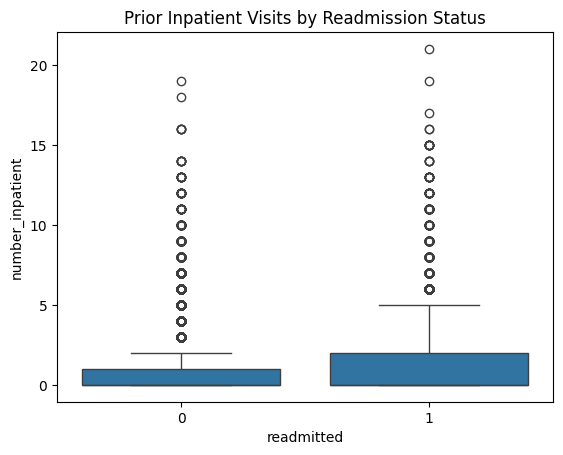

In [69]:
sns.boxplot(data=df, x='readmitted', y='number_inpatient')
plt.title('Prior Inpatient Visits by Readmission Status')
plt.show()

#### Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

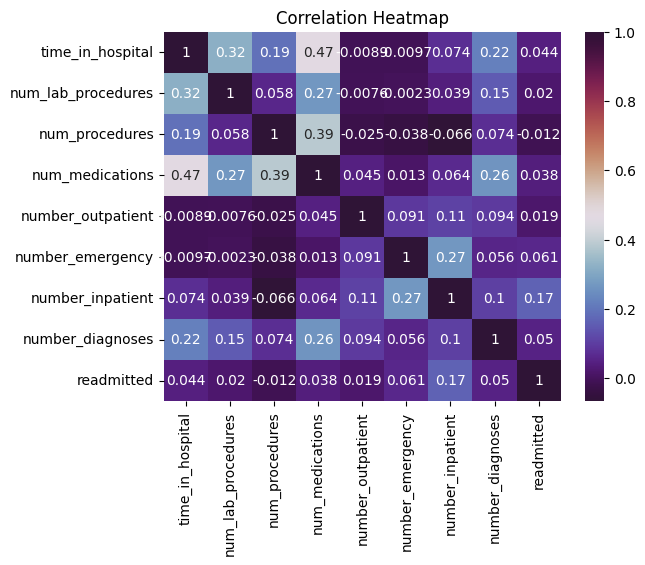

In [70]:
numerical_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'readmitted'
]

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='twilight_shifted')
plt.title('Correlation Heatmap')

#### Medication Analysis

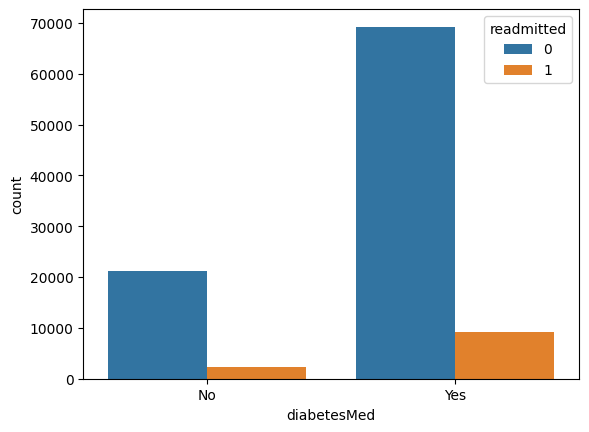

In [75]:
sns.countplot(data=df, x='diabetesMed', hue='readmitted')
plt.show()

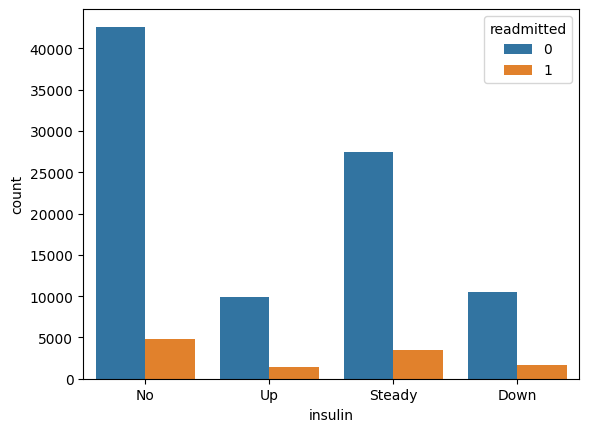

In [76]:
sns.countplot(data=df, x='insulin', hue='readmitted')
plt.show()

#### Export Cleaned Dataset

In [81]:
df.to_csv('diabetic_data_1.csv', index=False)

### Key Insights

- Replaced missing values represented by '?' with NaN and handled them appropriately to improve data quality.
- Removed columns (weight, max_glu_serum, and A1Cresult) with a high proportion of missing values.
- Filled missing values in categorical columns such as race, payer_code, medical_specialty, and diagnosis fields with "Unknown" to retain valuable patient records.
- Converted the target variable **readmitted** into a binary classification problem, where **1** represents readmission within 30 days and **0** represents no readmission within 30 days.
- Dropped identifier columns (encounter_id and patient_nbr) as they do not contribute to model prediction.
- Exploratory Data Analysis (EDA) indicated that patients with longer hospital stays, more medications, and a higher number of previous inpatient visits were more likely to be readmitted.
- The target variable showed a clear class imbalance, with significantly fewer patients readmitted within 30 days.
- The cleaned dataset was exported as diabetic_data_1.csv and used for model building and deployment.